<a href="https://colab.research.google.com/github/Jbaner/OMDSModC_Capstone_Project/blob/main/OMDS_ModC_Week11_Banerjee_Jayeeta_Data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Clustering: Part 2

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [2]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
713,16,1.0,16.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
604,23,3.0,17.0,2.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
120,33,1.0,16.0,4.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
208,27,4.0,16.0,1.0,0.0,0.0,0.000,1.0,0.67,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
380,18,3.0,15.0,1.0,1.0,2.0,0.003,1.0,0.58,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
813,20,1.0,17.0,NaN,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
575,17,2.0,15.0,1.0,0.0,0.0,0.000,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
266,21,2.0,19.0,1.0,0.0,0.0,0.000,1.0,1.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
557,27,2.0,17.0,3.0,0.0,0.0,0.000,1.0,0.25,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
822,36,3.0,20.0,2.0,0.0,0.0,0.000,1.0,6.00,0.0,...,16.0,16.0,1,0,1,1,0,0,0,0


In [3]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)","STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA


#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [6]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

# Number of clusters
clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("Number of clusters:", clusters)

print(
    "Noise points:",
    list(dbscan_labels).count(-1))

Number of clusters: 4
Noise points: 143


In [7]:
#Check Number of Clusters and Noise Points
unique, counts = np.unique(
    dbscan_labels,
    return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(143), np.int64(0): np.int64(695), np.int64(1): np.int64(5), np.int64(2): np.int64(11), np.int64(3): np.int64(4)}


In [8]:
for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5,
        metric="euclidean")

    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        "eps:",
        eps,
        "Clusters:",
        n_clusters,
        "Noise:",
        n_noise
    )

eps: 0.5 Clusters: 13 Noise: 530
eps: 0.7 Clusters: 7 Noise: 419
eps: 0.9 Clusters: 3 Noise: 279
eps: 1.1 Clusters: 2 Noise: 218
eps: 1.3 Clusters: 2 Noise: 181
eps: 1.5 Clusters: 4 Noise: 143
eps: 2.0 Clusters: 4 Noise: 80


In [9]:
#DBSCAN Silhouette Score
dbscan = DBSCAN(
    eps=2.0,
    min_samples=5,
    metric="euclidean")

dbscan_labels = dbscan.fit_predict(X_scaled)

mask = dbscan_labels != -1
n_clusters = len(
    set(dbscan_labels[mask]))

if n_clusters > 1:

    score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask])

    print("DBSCAN Clusters:", n_clusters)
    print("DBSCAN Silhouette Score:", round(score,4))

else:
    print(
        "Silhouette score cannot be calculated."
        " DBSCAN found fewer than 2 clusters.")

DBSCAN Clusters: 4
DBSCAN Silhouette Score: 0.4308


In [11]:
#Stability Check

X_sample1, X_sample2 = train_test_split(
    X_scaled,
    test_size=0.2,
    random_state=42)

dbscan = DBSCAN(eps=2.0, min_samples=5)


labels1 = dbscan.fit_predict(X_sample1)
clusters1 = len(set(labels1)) - (1 if -1 in labels1 else 0)

print("Clusters in sample:",clusters1)

clusters = dbscan.fit_predict(X_scaled)

df_CivicalCancer_nw["DBSCAN_cluster"] = clusters

print(df_CivicalCancer_nw["DBSCAN_cluster"].value_counts())

Clusters in sample: 4
DBSCAN_cluster
 0    742
-1     80
 3     19
 1      9
 2      8
Name: count, dtype: int64


/tmp/ipykernel_826/800851972.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["DBSCAN_cluster"] = clusters


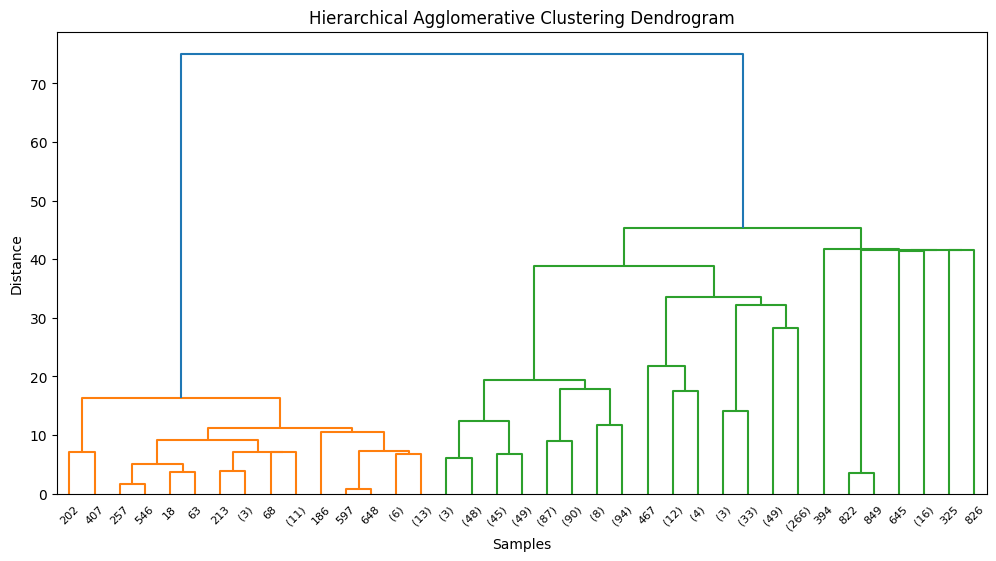

In [12]:
#Hierarchical Agglomerative Clustering
plt.figure(figsize=(12,6))

linked = linkage(
    X_scaled,
    method="ward")

dendrogram(
    linked,
    truncate_mode="level",
    p=5)

plt.title("Hierarchical Agglomerative Clustering Dendrogram")

plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

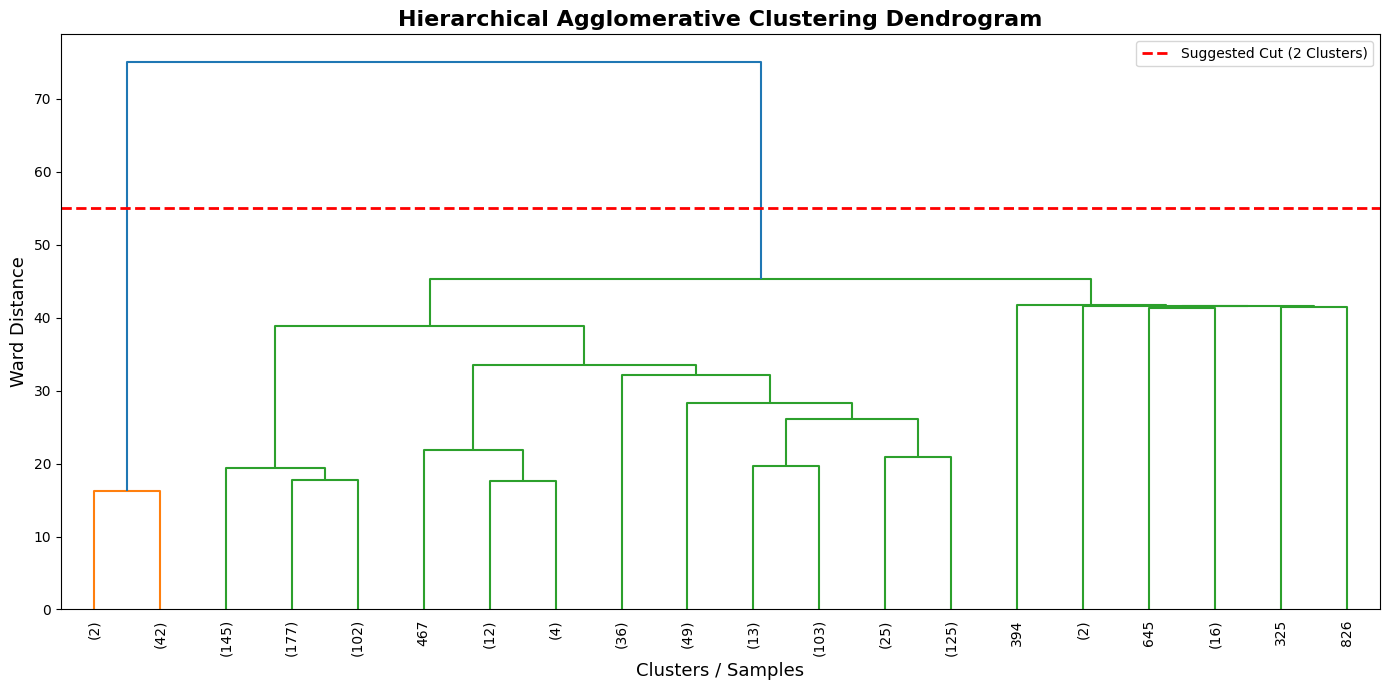

In [13]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute hierarchical clustering
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode='lastp',   # Show only the last p merged clusters
    p=20,                    # Number of leaf clusters to display
    leaf_rotation=90,
    leaf_font_size=10,
    show_leaf_counts=True
)

# Optional: Draw a horizontal line to indicate a possible cut
plt.axhline(y=55, color='red', linestyle='--', linewidth=2,
            label='Suggested Cut (2 Clusters)')

plt.title("Hierarchical Agglomerative Clustering Dendrogram",
          fontsize=16, fontweight='bold')
plt.xlabel("Clusters / Samples", fontsize=13)
plt.ylabel("Ward Distance", fontsize=13)

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# linkage_methods
linkage_methods = ["ward","complete","average", "single"]

for method in linkage_methods:
    hac = AgglomerativeClustering(
        n_clusters=2,
        linkage=method)

    labels = hac.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels)

    print( method,
        "Silhouette Score:",
        round(score,4))

ward Silhouette Score: 0.609
complete Silhouette Score: 0.8585
average Silhouette Score: 0.8585
single Silhouette Score: 0.8585


In [15]:
hac_labels = hac.fit_predict(X_scaled)
df_CivicalCancer_nw["HAC_cluster"] = hac_labels

df_CivicalCancer_nw["HAC_cluster"].value_counts()

/tmp/ipykernel_826/1553206484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["HAC_cluster"] = hac_labels


,count
HAC_cluster,
0,857
1,1


In [17]:
pd.crosstab(
    df_CivicalCancer_nw["HAC_cluster"],
    df_CivicalCancer_nw["Biopsy"]
)

Biopsy,0,1
HAC_cluster,,
0,802,55
1,1,0


In [19]:
df_CivicalCancer_nw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    float64
 2   First sexual intercourse            858 non-null    float64
 3   Num of pregnancies                  858 non-null    float64
 4   Smokes (packs/year)                 858 non-null    float64
 5   Hormonal Contraceptives (years)     858 non-null    float64
 6   IUD (years)                         858 non-null    float64
 7   STDs (number)                       858 non-null    float64
 8   STDs: Number of diagnosis           858 non-null    int64  
 9   STDs:condylomatosis                 858 non-null    float64
 10  STDs:vulvo-perineal condylomatosis  858 non-null    float64
 11  STDs:syphilis                       858 non-n

In [20]:
# Add cluster labels to the dataset
df_cluster = df_CivicalCancer_nw.copy()
df_cluster["Cluster"] = hac_labels

# Select a few important features
cluster_summary = (
    df_cluster
    .groupby("Cluster")[[
        "Age",
        "Number of sexual partners",
        "Num of pregnancies",
        "STDs: Number of diagnosis",
        "IUD (years)",
        "STDs:Hepatitis B"
    ]]
    .mean()
    .round(2)
)

print(cluster_summary)

           Age  Number of sexual partners  Num of pregnancies  \
Cluster                                                         
0        26.83                       2.51                2.26   
1        20.00                       2.00                1.00   

         STDs: Number of diagnosis  IUD (years)  STDs:Hepatitis B  
Cluster                                                            
0                             0.09         0.45               0.0  
1                             1.00         0.00               1.0  


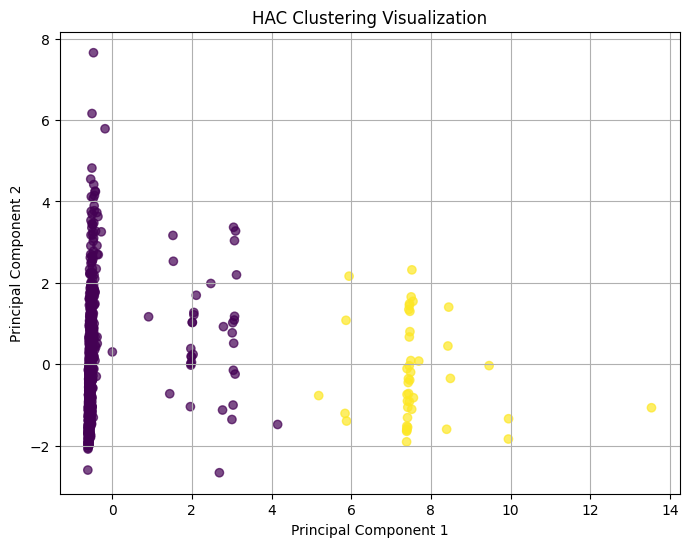

In [21]:
# AgglomerativeClustering
hac = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward")

hac_labels = hac.fit_predict(X_scaled)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hac_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("HAC Clustering Visualization")

plt.grid(True)
plt.show()

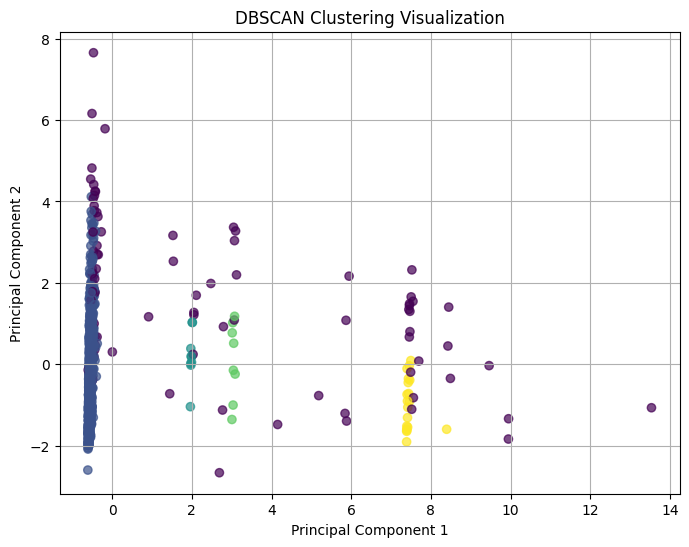

In [22]:
#Visualize DBSCAN Clusters Using PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering Visualization")

plt.grid(True)

plt.show()

In [23]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

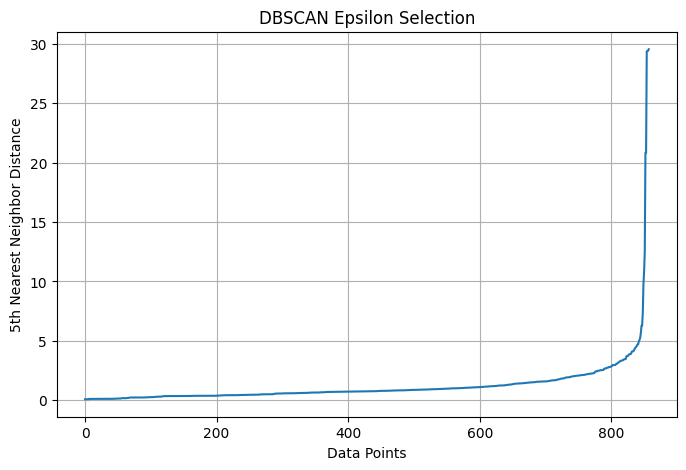

In [24]:
from sklearn.neighbors import NearestNeighbors

#Find Good eps Value (Tuning Step)
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")

plt.title("DBSCAN Epsilon Selection")

plt.grid(True)

plt.show()

In [25]:
#Check noise
dbscan = DBSCAN(eps=3, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

df_CivicalCancer_nw["DBSCAN_cluster"] = clusters

print(df_CivicalCancer_nw["DBSCAN_cluster"].value_counts())

DBSCAN_cluster
 0    769
-1     34
 1     31
 3     13
 2     11
Name: count, dtype: int64


/tmp/ipykernel_826/3546212698.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["DBSCAN_cluster"] = clusters


In [26]:
#Examine the noise samples
noise_points = df_CivicalCancer_nw[
    df_CivicalCancer_nw["DBSCAN_cluster"] == -1
]

noise_points.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes (packs/year),Hormonal Contraceptives (years),IUD (years),STDs (number),STDs: Number of diagnosis,STDs:condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:Hepatitis B,STDs:HPV,Biopsy,DBSCAN_cluster,HAC_cluster
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.0,34.000000
mean,34.470588,3.764706,17.441176,3.000000,4.015777,2.272059,1.154412,1.323529,0.588235,0.382353,0.352941,0.147059,0.029412,0.029412,0.029412,0.029412,0.058824,0.088235,-1.0,0.029412
std,17.382045,4.930172,3.653070,2.534609,8.594528,3.746396,2.603912,1.147344,0.743360,0.493270,0.485071,0.359491,0.171499,0.171499,0.171499,0.171499,0.238833,0.287902,0.0,0.171499
min,16.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
25%,22.250000,2.000000,16.000000,1.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
50%,31.000000,3.000000,17.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
75%,36.000000,4.000000,19.000000,4.000000,2.150000,3.750000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.000000
max,84.000000,28.000000,28.000000,11.000000,37.000000,14.000000,10.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.0,1.000000


In [27]:
#Identify features driving the outliers
noise_scaled = pd.DataFrame(
    X_scaled[clusters == -1],
    columns=X.columns
)

feature_deviation = noise_scaled.abs().mean().sort_values(
    ascending=False
)

print(feature_deviation.head(10))

STDs (number)                         2.379901
STDs: Number of diagnosis             1.962431
Smokes (packs/year)                   1.861138
STDs:condylomatosis                   1.788162
STDs:vulvo-perineal condylomatosis    1.685178
Age                                   1.427314
Number of sexual partners             1.287429
STDs:HPV                              1.262444
Num of pregnancies                    1.188427
STDs:syphilis                         1.129461
dtype: float64


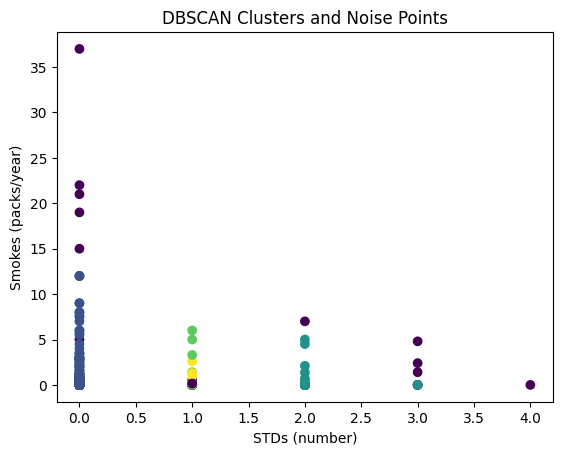

In [28]:
#Visualize important noisy features

plt.scatter(
    df_CivicalCancer_nw["STDs (number)"],
    df_CivicalCancer_nw["Smokes (packs/year)"],
    c=clusters )

plt.xlabel("STDs (number)")
plt.ylabel("Smokes (packs/year)")
plt.title("DBSCAN Clusters and Noise Points")
plt.show()